# Spatial Analysis of Cultural Participation in India

> **Note:** This exploratory notebook is **not part of the rendered manuscript** (it is not registered in `_quarto.yml`); the manuscript's cultural-participation results are produced by `c06_spatial_culture.ipynb`, which supersedes it. Retained for provenance.

This notebook performs an Exploratory Spatial Data Analysis (ESDA) of cultural participation across Indian states using data from the NSS 47th Round (1991-92).
The first critical step is harmonizing region names between the Stata data file (32 states/UTs) and the GeoJSON map (36 regions), then creating a 32-region map consistent with the data.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

## 1. Load Data

In [ ]:
# Load Stata cultural data (NSS 47th Round, 1991-92)
df_stata = pd.read_stata("../data/Cultural_Data_India/Final_state_LC_CH.dta")
print(f"Stata data: {df_stata.shape[0]} states, {df_stata.shape[1]} columns")
print(f"Columns: {list(df_stata.columns)}")
df_stata.head()

Stata data: 32 states, 7 columns
Columns: ['State_num', 'LC_Performance', 'LC_Telecast', 'SC', 'CH_relig', 'LC_shows', 'Sports']


,State_num,LC_Performance,LC_Telecast,SC,CH_relig,LC_shows,Sports
0,A & N Islands,-0.039257,0.218096,0.105269,-0.142054,1.016912,-0.229062
1,Andhra Pradesh,-0.011268,0.259332,-0.003002,-0.103771,-0.137962,-0.306077
2,Arunachal Pradesh,0.025483,-0.498378,0.044571,-0.104606,0.067274,-0.113826
3,Assam,-0.009383,-0.050606,0.091993,0.275306,-0.124625,-0.038665
4,Bihar,-0.011525,-0.283571,-0.015918,-0.083530,-0.095251,0.141808


In [ ]:
# Load GeoJSON map (36 regions, ~2014-2019 administrative divisions)
gdf36 = gpd.read_file("../data/maps/india36.geojson")
print(f"GeoJSON: {gdf36.shape[0]} regions")
print(f"Properties: {list(gdf36.columns)}")
gdf36.head()

GeoJSON: 36 regions
Properties: ['id', 'region', 'geometry']


,id,region,geometry
0,1,Andaman and Nicobar Islands,"MULTIPOLYGON (((93.84861 7.24051, 93.80986 7.2..."
1,2,Andhra Pradesh,"MULTIPOLYGON (((81.1061 17.82436, 81.09749 17...."
2,3,Arunachal Pradesh,"MULTIPOLYGON (((95.2373 26.67984, 95.25969 26...."
3,4,Assam,"MULTIPOLYGON (((95.19587 27.03716, 95.21414 27..."
4,5,Bihar,"MULTIPOLYGON (((88.11223 26.53886, 88.0997 26...."


## 2. Name Harmonization

### 2.1 Side-by-side comparison of region names

In [ ]:
stata_names = sorted(df_stata["State_num"].unique())
geojson_names = sorted(gdf36["region"].unique())

print(f"Stata: {len(stata_names)} states")
print(f"GeoJSON: {len(geojson_names)} regions")
print()

# Show exact matches
exact_matches = set(stata_names) & set(geojson_names)
print(f"--- Exact matches ({len(exact_matches)}) ---")
for name in sorted(exact_matches):
    print(f"  {name}")

# Show names only in Stata
stata_only = set(stata_names) - set(geojson_names)
print(f"\n--- In Stata only ({len(stata_only)}) ---")
for name in sorted(stata_only):
    print(f"  {name}")

# Show names only in GeoJSON
geojson_only = set(geojson_names) - set(stata_names)
print(f"\n--- In GeoJSON only ({len(geojson_only)}) ---")
for name in sorted(geojson_only):
    print(f"  {name}")

Stata: 32 states
GeoJSON: 36 regions

--- Exact matches (23) ---
  Andhra Pradesh
  Arunachal Pradesh
  Assam
  Bihar
  Goa
  Gujarat
  Haryana
  Himachal Pradesh
  Karnataka
  Kerala
  Madhya Pradesh
  Maharashtra
  Manipur
  Meghalaya
  Mizoram
  Nagaland
  Punjab
  Rajasthan
  Sikkim
  Tamil Nadu
  Tripura
  Uttar Pradesh
  West Bengal

--- In Stata only (9) ---
  A & N Islands
  Chandigarh
  Dadra & Nagar Haveli
  Daman & Diu
  Delhi
  Jammu & Kashmir
  Lakshdweep
  Orissa
  Pondicherry

--- In GeoJSON only (13) ---
  Andaman and Nicobar Islands
  Chandigarth
  Chhattisgarh
  Dadra and Nagar Haveli
  Daman and Diu
  Jammu and Kashmir
  Jharkhand
  Lakshadweep
  NCT of Delhi
  Odisha
  Puducherry
  Telangana
  Uttarakhand


### 2.2 Verified name mapping

Each mapping has been verified via web research. We rename GeoJSON names to match the Stata conventions.

| # | Stata name | GeoJSON name | Reason |
|---|-----------|-------------|--------|
| 1 | A & N Islands | Andaman and Nicobar Islands | Survey abbreviation vs full official name |
| 2 | Chandigarh | Chandigarth | **Typo in GeoJSON** — correct spelling is "Chandigarh" |
| 3 | Dadra & Nagar Haveli | Dadra and Nagar Haveli | `&` vs `and` |
| 4 | Daman & Diu | Daman and Diu | `&` vs `and` |
| 5 | Delhi | NCT of Delhi | Short name vs official name |
| 6 | Jammu & Kashmir | Jammu and Kashmir | `&` vs `and` |
| 7 | Lakshdweep | Lakshadweep | **Typo in Stata** — correct is "Lakshadweep"; we use the Stata spelling for consistency |
| 8 | Orissa | Odisha | Old name (pre-2011 rename) |
| 9 | Pondicherry | Puducherry | Old name (pre-2006 rename) |

In [ ]:
# Mapping: GeoJSON name -> Stata name (harmonize to Stata conventions)
geojson_to_stata = {
    "Andaman and Nicobar Islands": "A & N Islands",
    "Chandigarth": "Chandigarh",        # Fix GeoJSON typo
    "Dadra and Nagar Haveli": "Dadra & Nagar Haveli",
    "Daman and Diu": "Daman & Diu",
    "NCT of Delhi": "Delhi",
    "Jammu and Kashmir": "Jammu & Kashmir",
    "Lakshadweep": "Lakshdweep",         # Match Stata typo for merge
    "Odisha": "Orissa",                  # Old name used in Stata
    "Puducherry": "Pondicherry",         # Old name used in Stata
}

# Apply name harmonization to GeoJSON
gdf36["region_harmonized"] = gdf36["region"].replace(geojson_to_stata)

# Verify the mapping worked
print("Name changes applied:")
changed = gdf36[gdf36["region"] != gdf36["region_harmonized"]][["region", "region_harmonized"]]
print(changed.to_string(index=False))

Name changes applied:
                     region    region_harmonized
Andaman and Nicobar Islands        A & N Islands
                Chandigarth           Chandigarh
     Dadra and Nagar Haveli Dadra & Nagar Haveli
              Daman and Diu          Daman & Diu
          Jammu and Kashmir      Jammu & Kashmir
                Lakshadweep           Lakshdweep
               NCT of Delhi                Delhi
                     Odisha               Orissa
                 Puducherry          Pondicherry


### 2.3 Compatibility report after harmonization

In [ ]:
harmonized_names = set(gdf36["region_harmonized"].unique())
stata_name_set = set(stata_names)

matched = harmonized_names & stata_name_set
geojson_unmatched = harmonized_names - stata_name_set
stata_unmatched = stata_name_set - harmonized_names

print(f"=== Compatibility Report ===")
print(f"Matched regions: {len(matched)} of {len(stata_name_set)} Stata states")
print(f"GeoJSON regions without Stata data: {len(geojson_unmatched)}")
print(f"Stata states without GeoJSON match: {len(stata_unmatched)}")

if geojson_unmatched:
    print(f"\nGeoJSON-only (newer states, no data):")
    for name in sorted(geojson_unmatched):
        print(f"  {name}")

if stata_unmatched:
    print(f"\n*** WARNING: Stata states with no GeoJSON match ***")
    for name in sorted(stata_unmatched):
        print(f"  {name}")
else:
    print("\nAll Stata states have a GeoJSON match.")

=== Compatibility Report ===
Matched regions: 32 of 32 Stata states
GeoJSON regions without Stata data: 4
Stata states without GeoJSON match: 0

GeoJSON-only (newer states, no data):
  Chhattisgarh
  Jharkhand
  Telangana
  Uttarakhand

All Stata states have a GeoJSON match.


## 3. Create 32-Region Map (Dissolve Newer States)

The 4 newer states that don't exist in the Stata data were carved from parent states after 1991-92:

| Newer state | Carved from | Year |
|------------|-------------|------|
| Chhattisgarh | Madhya Pradesh | 2000 |
| Jharkhand | Bihar | 2000 |
| Uttarakhand | Uttar Pradesh | 2000 |
| Telangana | Andhra Pradesh | 2014 |

We dissolve these back into their parent states to create a 32-region map matching the Stata data.

In [ ]:
# Map newer states to their parent states
dissolve_map = {
    "Chhattisgarh": "Madhya Pradesh",
    "Jharkhand": "Bihar",
    "Uttarakhand": "Uttar Pradesh",
    "Telangana": "Andhra Pradesh",
}

# Create dissolve column: use harmonized name, but remap newer states to parents
gdf36["region_dissolve"] = gdf36["region_harmonized"].replace(dissolve_map)

print("Regions to be dissolved:")
dissolved = gdf36[gdf36["region_harmonized"] != gdf36["region_dissolve"]][
    ["region_harmonized", "region_dissolve"]
]
print(dissolved.to_string(index=False))

Regions to be dissolved:
region_harmonized region_dissolve
     Chhattisgarh  Madhya Pradesh
        Jharkhand           Bihar
        Telangana  Andhra Pradesh
      Uttarakhand   Uttar Pradesh


In [ ]:
# Dissolve geometries by the dissolve column
# Select only the dissolve key + geometry to avoid duplicate column issues
gdf_prep = gdf36[["region_dissolve", "geometry"]].copy()
gdf32 = gdf_prep.dissolve(by="region_dissolve").reset_index()
gdf32 = gdf32.rename(columns={"region_dissolve": "region"})

print(f"New map: {len(gdf32)} regions")
assert len(gdf32) == 32, f"Expected 32 regions, got {len(gdf32)}"
print("32-region map created successfully.")

New map: 32 regions
32-region map created successfully.


In [ ]:
# Save the 32-region GeoJSON
gdf32.to_file("../data/maps/india32.geojson", driver="GeoJSON")
print("Saved: data/maps/india32.geojson")

Saved: data/maps/india32.geojson


### 3.1 Verification: boundary plot

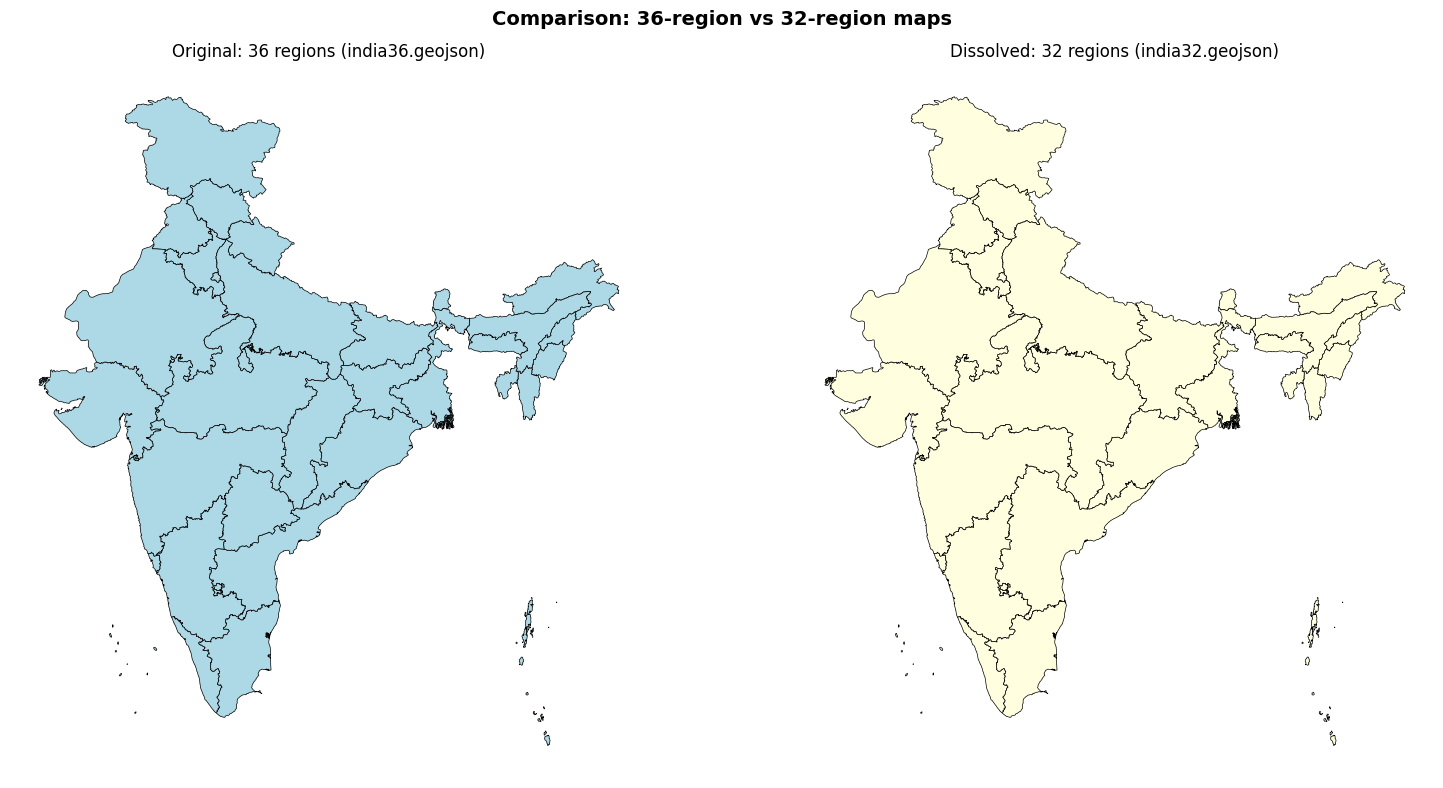

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

gdf36.plot(ax=axes[0], edgecolor="black", facecolor="lightblue", linewidth=0.5)
axes[0].set_title(f"Original: {len(gdf36)} regions (india36.geojson)")
axes[0].set_axis_off()

gdf32.plot(ax=axes[1], edgecolor="black", facecolor="lightyellow", linewidth=0.5)
axes[1].set_title(f"Dissolved: {len(gdf32)} regions (india32.geojson)")
axes[1].set_axis_off()

plt.suptitle("Comparison: 36-region vs 32-region maps", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Merge Cultural Data with Map

In [ ]:
# Merge: 32-region GeoJSON + Stata cultural data
gdf_merged = gdf32.merge(df_stata, left_on="region", right_on="State_num", how="left")

# Check for any unmatched regions
n_matched = gdf_merged["State_num"].notna().sum()
n_missing = gdf_merged["State_num"].isna().sum()
print(f"Matched: {n_matched} / {len(gdf32)} regions")
print(f"Missing data: {n_missing}")

if n_missing > 0:
    print("\n*** WARNING: Unmatched regions ***")
    print(gdf_merged[gdf_merged["State_num"].isna()]["region"].tolist())
else:
    print("\nPerfect merge: all 32 regions have cultural data.")

gdf_merged.head()

Matched: 32 / 32 regions
Missing data: 0

Perfect merge: all 32 regions have cultural data.


,region,geometry,State_num,LC_Performance,LC_Telecast,SC,CH_relig,LC_shows,Sports
0,A & N Islands,"MULTIPOLYGON (((92.77383 9.12596, 92.73327 9.1...",A & N Islands,-0.039257,0.218096,0.105269,-0.142054,1.016912,-0.229062
1,Andhra Pradesh,"MULTIPOLYGON (((81.20038 17.85444, 81.26252 17...",Andhra Pradesh,-0.011268,0.259332,-0.003002,-0.103771,-0.137962,-0.306077
2,Arunachal Pradesh,"POLYGON ((95.2373 26.67984, 95.25969 26.67984,...",Arunachal Pradesh,0.025483,-0.498378,0.044571,-0.104606,0.067274,-0.113826
3,Assam,"POLYGON ((95.19587 27.03716, 95.21414 27.02763...",Assam,-0.009383,-0.050606,0.091993,0.275306,-0.124625,-0.038665
4,Bihar,"POLYGON ((87.77667 25.1529, 87.77827 25.09978,...",Bihar,-0.011525,-0.283571,-0.015918,-0.083530,-0.095251,0.141808


## 5. Choropleth Maps

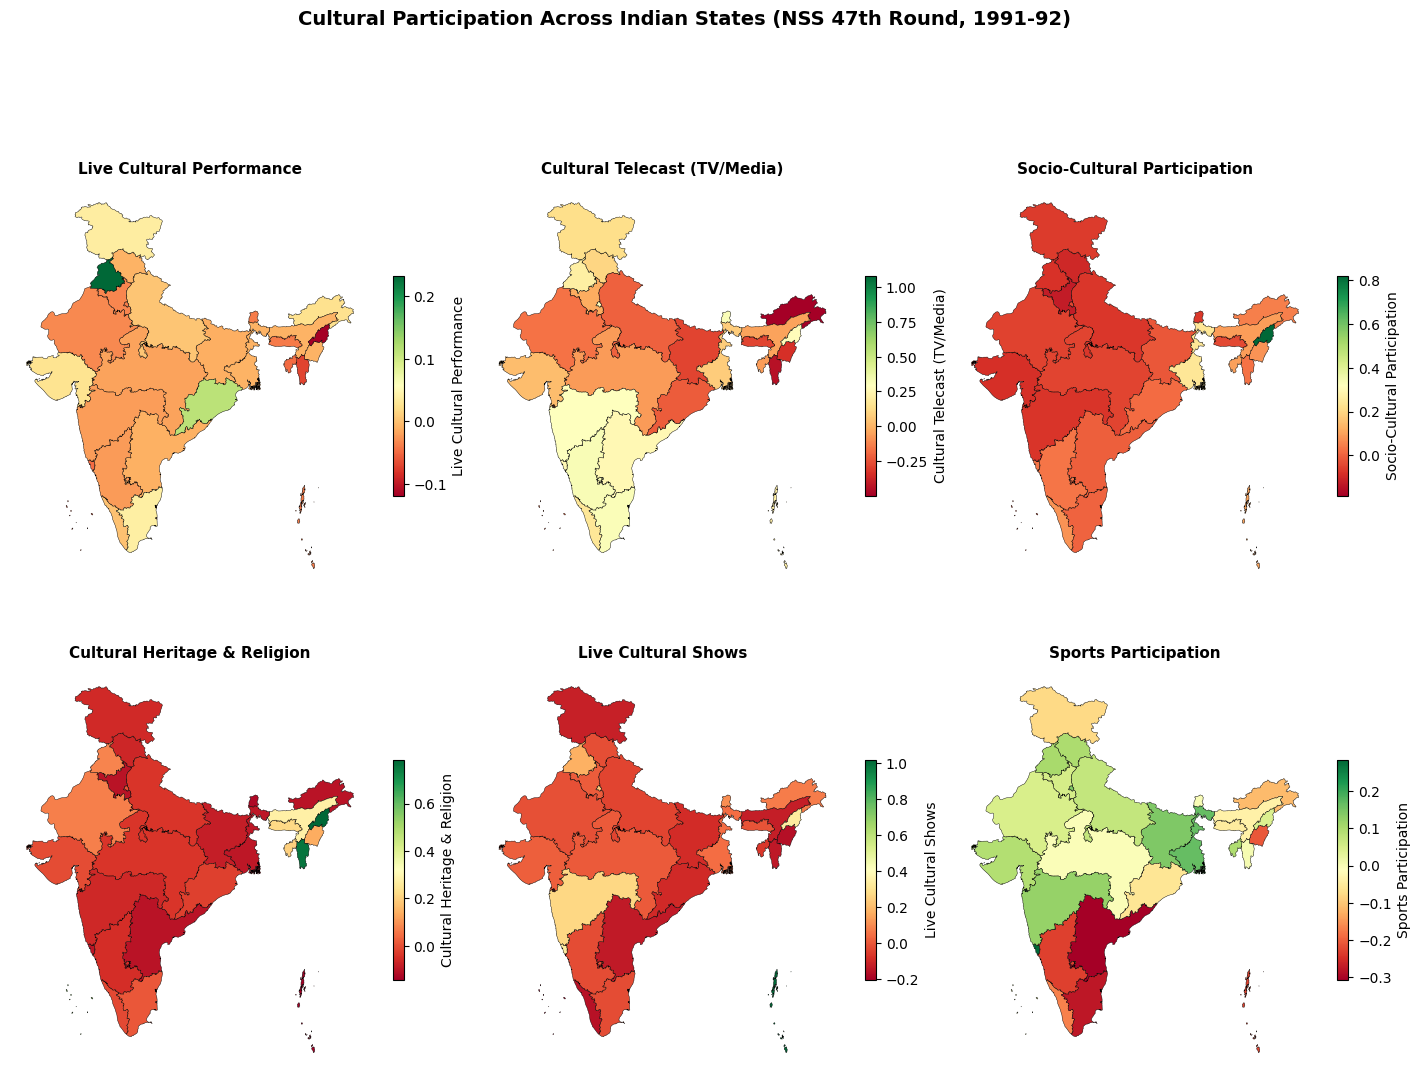

In [ ]:
variables = ["LC_Performance", "LC_Telecast", "SC", "CH_relig", "LC_shows", "Sports"]
var_labels = {
    "LC_Performance": "Live Cultural\nPerformance",
    "LC_Telecast": "Cultural\nTelecast",
    "SC": "Socio-Cultural\nParticipation",
    "CH_relig": "Cultural Heritage\n& Religion",
    "LC_shows": "Live Cultural\nShows",
    "Sports": "Sports\nParticipation",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 14))
axes = axes.flatten()

for i, var in enumerate(variables):
    gdf_merged.plot(
        column=var,
        ax=axes[i],
        legend=True,
        legend_kwds={"shrink": 0.6, "label": var},
        cmap="RdYlGn",
        edgecolor="black",
        linewidth=0.3,
        missing_kwds={"color": "lightgray", "label": "No data"},
    )
    axes[i].set_title(var_labels.get(var, var), fontsize=11, fontweight="bold")
    axes[i].set_axis_off()

plt.suptitle(
    "Cultural Participation Across Indian States (NSS 47th Round, 1991-92)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [ ]:
# Summary statistics
print("Summary Statistics of Cultural Variables")
print("=" * 60)
print(gdf_merged[variables].describe().round(3))

Summary Statistics of Cultural Variables
       LC_Performance  LC_Telecast      SC  CH_relig  LC_shows  Sports
count          32.000       32.000  32.000    32.000    32.000  32.000
mean           -0.013        0.051   0.019     0.047     0.037  -0.007
std             0.061        0.315   0.168     0.239     0.242   0.148
min            -0.118       -0.498  -0.183    -0.142    -0.205  -0.306
25%            -0.041       -0.190  -0.065    -0.097    -0.124  -0.091
50%            -0.022        0.070  -0.020    -0.041    -0.024   0.001
75%            -0.007        0.264   0.052     0.072     0.077   0.096
max             0.233        1.083   0.820     0.785     1.017   0.284
